In [23]:
import os
import cv2
import numpy as np
import shutil
import random

In [27]:
base = "/content/drive/MyDrive/adl_project/Dataset_BUSI_with_GT"
output = "/content/drive/MyDrive/adl_project/training_data"
os.makedirs(f"{output}/images/train", exist_ok=True)
os.makedirs(f"{output}/images/val", exist_ok=True)
os.makedirs(f"{output}/labels/train", exist_ok=True)
os.makedirs(f"{output}/labels/val", exist_ok=True)


In [29]:
label_map = {"benign": 0, "malignant": 1}
split_ratio = 0.8

for cls in ["benign", "malignant"]:
    cls_dir = os.path.join(base, cls)
    all_files = [f for f in os.listdir(cls_dir) if f.lower().endswith(".png") and "mask" not in f.lower()]
    random.shuffle(all_files)
    split = int(len(all_files) * split_ratio)
    train_files, val_files = all_files[:split], all_files[split:]

    for subset, flist in zip(["train", "val"], [train_files, val_files]):
        for img_file in flist:
            # paths
            img_path = os.path.join(cls_dir, img_file)
            mask_name = img_file.replace("image", "mask")
            mask_path = os.path.join(cls_dir, mask_name)
            label_path = os.path.join(output, f"labels/{subset}/{img_file.replace('.png', '.txt')}")
            save_img = os.path.join(output, f"images/{subset}/{img_file}")

            if not os.path.exists(mask_path):
                print(f"Mask not found for {img_file}, skipping...")
                continue

            # read mask
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                continue
            h, w = mask.shape

            # find contours (tumor boundary)
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            with open(label_path, "w") as lf:
                for cnt in contours:
                    x, y, bw, bh = cv2.boundingRect(cnt)
                    # normalize
                    x_c = (x + bw / 2) / w
                    y_c = (y + bh / 2) / h
                    bw /= w
                    bh /= h
                    lf.write(f"{label_map[cls]} {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}\n")

            # copy image
            shutil.copy(img_path, save_img)

print("Conversion complete — YOLO detection dataset created successfully!")


Conversion complete — YOLO detection dataset created successfully!


In [41]:
yaml_content = """
train: '/content/drive/MyDrive/adl_project/training_data/images/train'
val: '/content/drive/MyDrive/adl_project/training_data/images/val'

nc: 2
names: ["benign", "malignant"]
"""

with open("/content/drive/MyDrive/adl_project/dataset.yaml", "w") as f:
    f.write(yaml_content)


In [52]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

# train
model.train(data="/content/drive/MyDrive/adl_project/dataset.yaml", epochs=10, imgsz=640, batch=16)


Ultralytics 8.3.205 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/adl_project/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c07ef09c5c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [86]:
from ultralytics import YOLO

# Train model
model = YOLO("yolov8n.pt")
results = model.train(
    data="/content/drive/MyDrive/adl_project/dataset.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    augment=True
)

from ultralytics.utils.plotting import plot_results
plot_results("runs/detect/train/metrics.csv")

Ultralytics 8.3.205 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/adl_project/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train10, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

AssertionError: No results.csv files found in /content/runs/detect/train, nothing to plot.

In [87]:
from ultralytics.utils.plotting import plot_results
from pathlib import Path

# Find the latest training folder
train_dir = sorted(Path("runs/detect").glob("train*"), key=lambda x: x.stat().st_mtime)[-1]

# Plot results from the CSV file (it’s called results.csv)
plot_results(train_dir / "results.csv")


image 1/1 /content/drive/MyDrive/adl_project/training_data/images/train/malignant (175).png: 544x640 1 malignant, 8.0ms
Speed: 3.9ms preprocess, 8.0ms inference, 1.5ms postprocess per image at shape (1, 3, 544, 640)


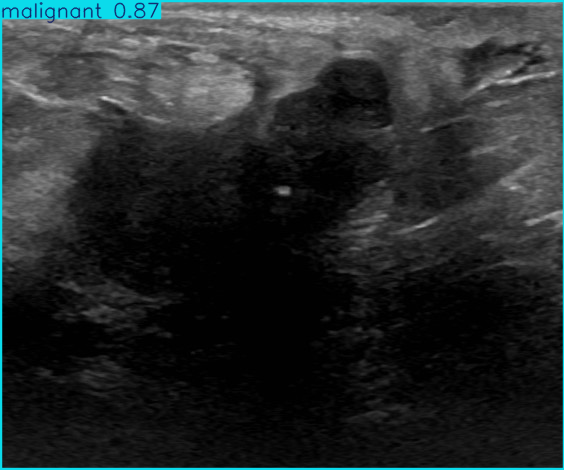

In [88]:
model = YOLO("/content/runs/detect/train9/weights/best.pt")
test = model("/content/drive/MyDrive/adl_project/training_data/images/train/malignant (175).png")
test[0].show()
